# Feature engineering Avanzato
## Fire count cell
numero di incendi che cade in una specifica cella geografica

In [18]:
df_pulito.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,dataset,chunk_start,chunk_end
0,37.11722,49.82455,308.68,1.00,1.00,2026-01-01,9,Aqua,MODIS,75,6.1NRT,281.47,12.23,N,MODIS_NRT,2025-12-31,2026-01-01
1,-25.37589,123.11378,329.29,2.07,1.40,2026-01-01,11,Terra,MODIS,76,6.1NRT,304.07,38.36,D,MODIS_NRT,2025-12-31,2026-01-01
2,-25.36225,123.12387,324.47,2.07,1.40,2026-01-01,11,Terra,MODIS,66,6.1NRT,304.35,21.46,D,MODIS_NRT,2025-12-31,2026-01-01
3,30.36209,47.33912,318.51,1.02,1.01,2026-01-01,11,Aqua,MODIS,97,6.1NRT,276.94,22.14,N,MODIS_NRT,2025-12-31,2026-01-01
4,30.39269,49.86965,314.71,1.06,1.03,2026-01-01,11,Aqua,MODIS,90,6.1NRT,278.23,19.04,N,MODIS_NRT,2025-12-31,2026-01-01


### Trasformazione coordinate in cella

In [19]:
import numpy as np

grid_size = 0.1

df_pulito["lat_cell"] = (
    np.floor(df_pulito["latitude"] / grid_size) * grid_size
).round(4)

df_pulito["lon_cell"] = (
    np.floor(df_pulito["longitude"] / grid_size) * grid_size
).round(4)

In [20]:
fire_counts = (
    df_pulito.groupby(["lat_cell", "lon_cell"])
      .agg(
          fire_count_cell=("latitude", "count"),
          frp_sum=("frp", "sum"),
          frp_mean=("frp", "mean")
      )
      .reset_index()
)

print(fire_counts)

        lat_cell  lon_cell  fire_count_cell  frp_sum    frp_mean
0          -57.9     -26.5                1    17.20   17.200000
1          -53.2      73.5                2   854.06  427.030000
2          -52.8     -68.6                1    84.11   84.110000
3          -52.8     170.5                1    16.78   16.780000
4          -51.9     -72.5                1     9.00    9.000000
...          ...       ...              ...      ...         ...
164039      69.3      88.1                5   241.10   48.220000
164040      70.4     -45.0                4     0.00    0.000000
164041      70.9      73.8                6   148.00   24.666667
164042      71.0      73.8                1     0.00    0.000000
164043      81.4      -6.0                1     0.00    0.000000

[164044 rows x 5 columns]


In [25]:
df_pulito = df_pulito.merge(
    fire_counts,
    on=["lat_cell", "lon_cell"],
    how="left"
)

In [26]:
df_pulito.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,...,daynight,dataset,chunk_start,chunk_end,lat_cell,lon_cell,fire_count_cell,frp_sum,frp_mean,geometry
0,37.11722,49.82455,308.68,1.00,1.00,2026-01-01,9,Aqua,MODIS,75,...,N,MODIS_NRT,2025-12-31,2026-01-01,37.1,49.8,1,12.23,12.230000,"POLYGON ((50.3 37.1, 50.3 37.6, 49.8 37.6, 49...."
1,-25.37589,123.11378,329.29,2.07,1.40,2026-01-01,11,Terra,MODIS,76,...,D,MODIS_NRT,2025-12-31,2026-01-01,-25.4,123.1,2,59.82,29.910000,"POLYGON ((123.6 -25.4, 123.6 -24.9, 123.1 -24...."
2,-25.36225,123.12387,324.47,2.07,1.40,2026-01-01,11,Terra,MODIS,66,...,D,MODIS_NRT,2025-12-31,2026-01-01,-25.4,123.1,2,59.82,29.910000,"POLYGON ((123.6 -25.4, 123.6 -24.9, 123.1 -24...."
3,30.36209,47.33912,318.51,1.02,1.01,2026-01-01,11,Aqua,MODIS,97,...,N,MODIS_NRT,2025-12-31,2026-01-01,30.3,47.3,208,4074.05,19.586779,"POLYGON ((47.8 30.3, 47.8 30.8, 47.3 30.8, 47...."
4,30.39269,49.86965,314.71,1.06,1.03,2026-01-01,11,Aqua,MODIS,90,...,N,MODIS_NRT,2025-12-31,2026-01-01,30.3,49.8,290,4700.85,16.209828,"POLYGON ((50.3 30.3, 50.3 30.8, 49.8 30.8, 49...."


In [27]:
df_pulito.to_csv("dataset_pulito.csv", index=False)

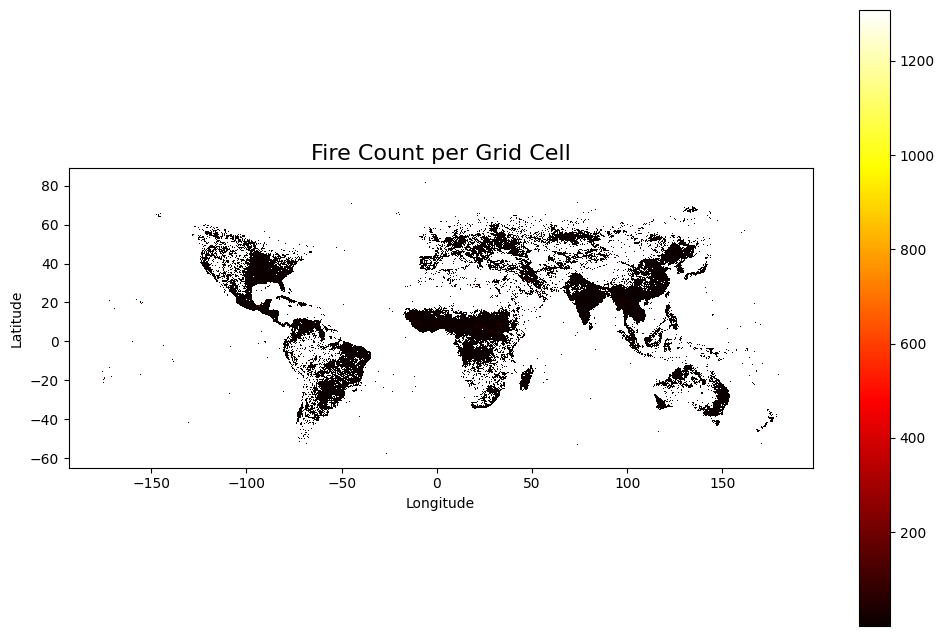

In [28]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box

grid_size = 0.5

fire_counts["geometry"] = fire_counts.apply(
    lambda row: box(
        row["lon_cell"],
        row["lat_cell"],
        row["lon_cell"] + grid_size,
        row["lat_cell"] + grid_size
    ),
    axis=1
)

gdf_grid = gpd.GeoDataFrame(
    fire_counts,
    geometry="geometry",
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(12, 8))

gdf_grid.plot(
    column="fire_count_cell",
    ax=ax,
    legend=True,
    cmap="hot",
    edgecolor="none"
)

ax.set_title("Fire Count per Grid Cell", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

# Fire density
Stima continua della densita' degli incendi nello spazio

density(x) = somma delle influenze di tutti i punti vicini. Ogni punto influisce con una gaussiana

In [29]:
coords = df_pulito[["latitude", "longitude"]].values

In [30]:
from sklearn.neighbors import KernelDensity

kde = KernelDensity(
    bandwidth=0.2,   # parametro fondamentale
    kernel="gaussian"
)

kde.fit(coords)

,"bandwidth bandwidth: float or {""scott"", ""silverman""}, default=1.0The bandwidth of the kernel. If bandwidth is a float, it defines thebandwidth of the kernel. If bandwidth is a string, one of the estimationmethods is implemented.",0.2
,"algorithm algorithm: {'kd_tree', 'ball_tree', 'auto'}, default='auto'The tree algorithm to use.",'auto'
,"kernel kernel: {'gaussian', 'tophat', 'epanechnikov', 'exponential', 'linear', 'cosine'}, default='gaussian'The kernel to use.",'gaussian'
,"metric metric: str, default='euclidean'Metric to use for distance computation. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.Not all metrics are valid with all algorithms: refer to thedocumentation of :class:`BallTree` and :class:`KDTree`. Note that thenormalization of the density output is correct only for the Euclideandistance metric.",'euclidean'
,"atol atol: float, default=0The desired absolute tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"rtol rtol: float, default=0The desired relative tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"breadth_first breadth_first: bool, default=TrueIf true (default), use a breadth-first approach to the problem.Otherwise use a depth-first approach.",True
,"leaf_size leaf_size: int, default=40Specify the leaf size of the underlying tree. See :class:`BallTree`or :class:`KDTree` for details.",40
,"metric_params metric_params: dict, default=NoneAdditional parameters to be passed to the tree for use with themetric. For more information, see the documentation of:class:`BallTree` or :class:`KDTree`.",None


In [ ]:
import numpy as np

density = np.exp(kde.score_samples(coords))

df_pulito["fire_density"] = density